# Project 1 — Online Retail Data Quality, Aggregation and Business Analysis

## Business scenario
You are a **Junior Data Analyst** working for a UK-based online retailer. The company has two years of transaction data stored in separate files, plus a product master table. Before management can use the data, you must inspect, combine, clean, validate, aggregate and summarize it for business analysis.

The project files contain **real transaction records** derived from the supplied *Online Retail II* workbook.

### Files
- `retail_2009_2010.csv`
- `retail_2010_2011.csv`
- `product_master.csv`

### Scope
Use techniques from **Lessons 1, 2 and 3**. Parts A–M focus on data preparation and quality. Parts N–T extend the same dataset into aggregation, group operations, MultiIndex, pivot tables and visualization.


## Learning objectives
By completing the project, you should be able to use Pandas to:

- inspect `Series`, `DataFrame` and `Index` objects;
- select and filter observations with `[]`, `.loc`, `.iloc`, Boolean masks and `.isin()`;
- diagnose and correct data types;
- detect and handle missing values and duplicates;
- combine data with `pd.concat()` and `pd.merge()`;
- create variables using arithmetic, `.apply()` and `.map()`;
- sort, rank and summarize data;
- use `unique()`, `value_counts()`, descriptive statistics and correlation;
- aggregate business data with `groupby()` and `.agg()`;
- distinguish and use GroupBy **filter**, **transform** and **apply**;
- work with hierarchical indexes using **MultiIndex**;
- reshape grouped results with `stack()` and `unstack()`;
- build multidimensional summaries with `pivot_table()`;
- create simple business charts using Pandas `.plot()`;
- explain the business meaning of data-quality and aggregation decisions.


In [68]:
import pandas as pd
import numpy as np


# Part A — Load and understand the data

### Task A1
Load the three CSV files into DataFrames named `retail_09`, `retail_10`, and `products`.

### Task A2
For each DataFrame:
1. display the first five observations;
2. find the number of rows and columns;
3. display the column names;
4. inspect the index.


In [69]:
# Your code here
retail_09=pd.read_csv('/Users/duc/Downloads/Data prepare & Visualization/Tutor/retail_2009_2010.csv')
retail_10=pd.read_csv('/Users/duc/Downloads/Data prepare & Visualization/Tutor/retail_2010_2011.csv')
products=pd.read_csv('/Users/duc/Downloads/Data prepare & Visualization/Tutor/product_master.csv')


# Part B — Diagnose the data

### Task B1
Use `.info()` to inspect both transaction DataFrames.

Answer:
- What is the data type of each variable?
- Which variables contain missing values?
- Is `InvoiceDate` stored as datetime?
- Is `Customer ID` a numerical measurement or an identifier? Explain.

### Task B2
Convert `InvoiceDate` to datetime in both files. Correct other data types if you think it is necessary. Run `.info()` again.

**Short interpretation:** Why do correct data types matter in business analysis?


In [70]:
# Your code here
retail_09.info()
retail_10.info()


<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  str    
 1   StockCode    525461 non-null  str    
 2   Quantity     525461 non-null  int64  
 3   InvoiceDate  525461 non-null  str    
 4   Price        525461 non-null  float64
 5   Customer ID  417534 non-null  float64
 6   Country      525461 non-null  str    
dtypes: float64(2), int64(1), str(4)
memory usage: 28.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  str    
 1   StockCode    541910 non-null  str    
 2   Quantity     541910 non-null  int64  
 3   InvoiceDate  541910 non-null  str    
 4   Price        541910 non-null  float64
 5   Customer ID  406830 non-null  float64
 6   Country

# Part C — Compare the two periods and combine them

### Task C1 — Arithmetic alignment challenge
Create two Series containing transaction-line counts by country:

```python
country_09 = retail_09['Country'].value_counts()
country_10 = retail_10['Country'].value_counts()
```

Subtract the two Series. What happens when a country exists in only one period? Then try `.sub(..., fill_value=0)` and explain how Pandas aligns values by index.

### Task C2 — Concatenate
Use `pd.concat()` to combine the two transaction DataFrames into one DataFrame called `retail`.

Answer:
- How many observations are in the combined dataset?
- Why is `ignore_index=True` useful here?
- Inspect `retail.head()`, `retail.tail()` and `retail.index`.


In [71]:
#C1
country_09=retail_09['Country'].value_counts()
country_10=retail_10['Country'].value_counts()


In [72]:
country_09.sub(country_10,fill_value=0).sort_values(ascending=False)

Country
EIRE                    1474.0
Sweden                   440.0
Netherlands              398.0
Greece                   371.0
United Arab Emirates     364.0
Channel Islands          148.0
Austria                  136.0
Lithuania                119.0
Bahrain                   88.0
Thailand                  76.0
Korea                     63.0
West Indies               54.0
RSA                       53.0
Malta                     45.0
Denmark                   39.0
Bermuda                   34.0
Nigeria                   32.0
Brazil                    30.0
Saudi Arabia             -10.0
Czech Republic           -30.0
Lebanon                  -32.0
USA                      -47.0
European Community       -61.0
Cyprus                   -68.0
Italy                    -72.0
Canada                   -74.0
Iceland                 -111.0
Singapore               -112.0
Japan                   -134.0
Unspecified             -136.0
Poland                  -147.0
Hong Kong               -212.0


In [73]:
# Your code here
#C2
retail=pd.concat([retail_09,retail_10],ignore_index=True)
display(len(retail),retail.head(),retail.tail(),retail.index)


1067371

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,1,2011-12-09 12:50:00,18.00,12680.0,France


RangeIndex(start=0, stop=1067371, step=1)

In [74]:
retail.shape

(1067371, 7)

In [75]:
retail_09.shape

(525461, 7)

# Part D — Data-quality audit

### Task D1 — Missing values
Count missing observations in every variable.

Answer:
- Which variables contain missing values?
- Which variable has the largest missing-data problem?
- What proportion of the dataset is missing for that variable?

### Task D2 — Think before deleting
Consider two questions:

1. *What is the total value of recorded transactions?*
2. *Which individual customers made the most valuable purchases?*

Would a missing `Customer ID` be equally important for both questions? Explain before deleting anything.

### Task D3 — Purposeful `dropna()`
Create a separate DataFrame named `customer_data` containing only rows with non-missing `Customer ID`. Keep the original `retail` unchanged. If appropriate, convert `Customer ID` in `customer_data` to integer.

### Task D4 — Duplicates
Count exact duplicated rows. Create `retail_clean` by removing exact duplicates.

Explain: Why can duplicated transaction rows distort business results?


In [76]:
#D1
missing_count=retail.isnull().sum()
missing_percentage=(retail.isnull().sum()/len(retail))*100
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage (%)': missing_percentage.round(2)
})
display(missing_summary)
# alter code
#missing=retail.isnull().sum().sort_values(ascending=False)
#missing

,Missing Count,Percentage (%)
Invoice,0,0.00
StockCode,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,243007,22.77
Country,0,0.00


In [77]:
#
customer_data=retail.dropna(subset=['Customer ID']).copy()
customer_data['Customer ID']=customer_data['Customer ID'].astype(int)
customer_data.head()

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


In [78]:
customer_data['Customer ID'].dtype

dtype('int64')

In [79]:
#Count duplicate
retail.duplicated().sum()

np.int64(34337)

In [80]:
#Create DataFrame
retail_clean=retail.drop_duplicates().copy()
retail_clean.duplicated().sum()

np.int64(0)

# Part E — Identify suspicious transactions

### Task E1 — Negative quantities
Find rows where `Quantity < 0`.
- How many are there?
- Display the first 10.
- Do negative quantities necessarily mean data-entry errors? Explain.

### Task E2 — Non-positive prices
Find rows where `Price <= 0`.
- How many are there?
- Display descriptive statistics for these rows.
- Should they automatically be deleted? Explain.

### Task E3 — Cancelled invoices with `.apply()`
The source workbook uses invoice values beginning with `C` for cancellations.

Write a function `classify_invoice(invoice)` returning `"Cancelled"` or `"Completed"`, then apply it to `Invoice` to create `InvoiceStatus`.

Use `value_counts()` to inspect the new variable.

### Task E4 — Practice `.map()`
Create `CancellationFlag` from `InvoiceStatus` using `.map()`:
- Completed → 0
- Cancelled → 1


In [81]:
# E1
negative_qty = retail_clean[retail_clean['Quantity'] < 0]
num_negative_qty = len(negative_qty)
print(num_negative_qty)

22496


In [82]:
# E2
non_positive_price = retail_clean[retail_clean['Price'] <= 0]
non_positive_price=len(non_positive_price)
print(non_positive_price)

6019


In [83]:
def classify_invoice(invoice):
    if str(invoice).upper().startswith('C'):
        return 'Canceled'
    else:
        return'Completed'
retail_clean['Invoice Status']=retail_clean['Invoice'].apply(classify_invoice)
retail_clean


,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country,Invoice Status
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Completed
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Completed
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Completed
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Completed
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Completed
...,...,...,...,...,...,...,...,...
1067366,581587,22899,6,2011-12-09 12:50:00,2.10,12680.0,France,Completed
1067367,581587,23254,4,2011-12-09 12:50:00,4.15,12680.0,France,Completed
1067368,581587,23255,4,2011-12-09 12:50:00,4.15,12680.0,France,Completed
1067369,581587,22138,3,2011-12-09 12:50:00,4.95,12680.0,France,Completed


In [84]:
# E3
def classify_invoice(invoice):
    if str(invoice).upper().startswith('C'):
        return 'Cancelled'
    else:
        return 'Completed'

retail_clean['InvoiceStatus'] = retail_clean['Invoice'].apply(classify_invoice)

retail_clean['InvoiceStatus'].value_counts()


InvoiceStatus
Completed    1013930
Cancelled      19104
Name: count, dtype: int64

In [85]:
# E4
retail_clean['CancellationFlag'] = retail_clean['InvoiceStatus'].map({
    'Completed': 0,
    'Cancelled': 1
})

retail_clean['CancellationFlag'].value_counts()


CancellationFlag
0    1013930
1      19104
Name: count, dtype: int64

# Part F — Create business variables

### Task F1 — Transaction value
Create:

`TotalAmount = Quantity × Price`

Report the mean, median, minimum and maximum and display `.describe()`.

Why can `TotalAmount` be negative?

### Task F2 — Value category
Create a function and use `.apply()` to classify `TotalAmount`:

| TotalAmount | ValueCategory |
|---:|---|
| `< 0` | Return / Cancellation |
| `0 to < 50` | Low Value |
| `50 to < 200` | Medium Value |
| `>= 200` | High Value |

Use `value_counts()` to inspect the result.


In [86]:
# F1
retail_clean['TotalAmount'] = retail_clean['Quantity'] * retail_clean['Price']
display(retail_clean['TotalAmount'].agg(['mean', 'median', 'min', 'max']))
display(retail_clean['TotalAmount'].describe())

# TotalAmount can be negative because Quantity can be negative (representing returns or cancellations).

# F2
def classify_value(amount):
    if amount < 0:
        return 'Return / Cancellation'
    elif amount < 50:
        return 'Low Value'
    elif amount < 200:
        return 'Medium Value'
    else:
        return 'High Value'

retail_clean['ValueCategory'] = retail_clean['TotalAmount'].apply(classify_value)
retail_clean['ValueCategory'].value_counts()


mean          18.252044
median         9.920000
min      -168469.600000
max       168469.600000
Name: TotalAmount, dtype: float64

count    1.033034e+06
mean     1.825204e+01
std      2.956871e+02
min     -1.684696e+05
25%      3.750000e+00
50%      9.920000e+00
75%      1.770000e+01
max      1.684696e+05
Name: TotalAmount, dtype: float64

ValueCategory
Low Value                951245
Medium Value              53193
Return / Cancellation     19108
High Value                 9488
Name: count, dtype: int64

# Part G — Selection and filtering

Use Boolean masks, `.loc`, `.iloc` or `.isin()` as appropriate.

1. Find transactions from **France, Germany and Spain** only.
2. Find rows where `Country == 'United Kingdom'` **and** `TotalAmount >= 500`.
3. Find rows where `Quantity > 100` **and** `Price > 10`.
4. Using `.iloc`, display the first 10 rows and first 4 columns.
5. Using `.loc`, display `Invoice`, `StockCode`, `Quantity`, `Price`, `TotalAmount` for high-value transactions (`TotalAmount >= 200`).


In [87]:
# G1
display(retail_clean[retail_clean['Country'].isin(['France', 'Germany', 'Spain'])])

# G2
display(retail_clean[(retail_clean['Country'] == 'United Kingdom') & (retail_clean['TotalAmount'] >= 500)])

# G3
display(retail_clean[(retail_clean['Quantity'] > 100) & (retail_clean['Price'] > 10)])

# G4
display(retail_clean.iloc[:10, :4])

# G5
display(retail_clean.loc[retail_clean['TotalAmount'] >= 200, ['Invoice', 'StockCode', 'Quantity', 'Price', 'TotalAmount']])


,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country,Invoice Status,InvoiceStatus,CancellationFlag,TotalAmount,ValueCategory
71,489439,22065,12,2009-12-01 09:28:00,1.45,12682.0,France,Completed,Completed,0,17.40,Low Value
72,489439,22138,9,2009-12-01 09:28:00,4.95,12682.0,France,Completed,Completed,0,44.55,Low Value
73,489439,22139,9,2009-12-01 09:28:00,4.95,12682.0,France,Completed,Completed,0,44.55,Low Value
74,489439,22352,12,2009-12-01 09:28:00,2.55,12682.0,France,Completed,Completed,0,30.60,Low Value
75,489439,85014A,3,2009-12-01 09:28:00,5.95,12682.0,France,Completed,Completed,0,17.85,Low Value
...,...,...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,6,2011-12-09 12:50:00,2.10,12680.0,France,Completed,Completed,0,12.60,Low Value
1067367,581587,23254,4,2011-12-09 12:50:00,4.15,12680.0,France,Completed,Completed,0,16.60,Low Value
1067368,581587,23255,4,2011-12-09 12:50:00,4.15,12680.0,France,Completed,Completed,0,16.60,Low Value
1067369,581587,22138,3,2011-12-09 12:50:00,4.95,12680.0,France,Completed,Completed,0,14.85,Low Value


,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country,Invoice Status,InvoiceStatus,CancellationFlag,TotalAmount,ValueCategory
575,489523,84879,800,2009-12-01 11:46:00,1.45,12931.0,United Kingdom,Completed,Completed,0,1160.00,High Value
2379,489597,DOT,1,2009-12-01 14:28:00,647.19,NaN,United Kingdom,Completed,Completed,0,647.19,High Value
3290,489675,15056BL,240,2009-12-02 09:47:00,4.60,13777.0,United Kingdom,Completed,Completed,0,1104.00,High Value
3296,489675,20679,120,2009-12-02 09:47:00,4.60,13777.0,United Kingdom,Completed,Completed,0,552.00,High Value
3306,489675,22041,240,2009-12-02 09:47:00,2.10,13777.0,United Kingdom,Completed,Completed,0,504.00,High Value
...,...,...,...,...,...,...,...,...,...,...,...,...
1065532,581459,22197,1200,2011-12-08 18:46:00,0.72,17949.0,United Kingdom,Completed,Completed,0,864.00,High Value
1065882,581483,23843,80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,Completed,Completed,0,168469.60,High Value
1065886,581485,20749,84,2011-12-09 09:38:00,6.35,17389.0,United Kingdom,Completed,Completed,0,533.40,High Value
1066369,581492,DOT,1,2011-12-09 10:03:00,933.17,NaN,United Kingdom,Completed,Completed,0,933.17,High Value


,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country,Invoice Status,InvoiceStatus,CancellationFlag,TotalAmount,ValueCategory
47514,493819,21843,144,2010-01-07 12:34:00,10.95,14156.0,EIRE,Completed,Completed,0,1576.80,High Value
51652,494120,21477,150,2010-01-11 12:48:00,10.95,14156.0,EIRE,Completed,Completed,0,1642.50,High Value
138801,502692,22423,156,2010-03-26 11:13:00,10.95,17949.0,United Kingdom,Completed,Completed,0,1708.20,High Value
152447,503871,84467,120,2010-04-08 11:36:00,25.49,NaN,United Kingdom,Completed,Completed,0,3058.80,High Value
167740,505235,22423,144,2010-04-21 10:50:00,10.95,17949.0,United Kingdom,Completed,Completed,0,1576.80,High Value
206459,509352,22606,200,2010-05-21 13:33:00,10.99,18102.0,United Kingdom,Completed,Completed,0,2198.00,High Value
229567,511556,22423,128,2010-06-09 10:02:00,10.95,17511.0,United Kingdom,Completed,Completed,0,1401.60,High Value
266850,515187,21737,104,2010-07-09 09:46:00,16.95,14156.0,EIRE,Completed,Completed,0,1762.80,High Value
287789,517391,22423,228,2010-07-29 09:19:00,10.95,17949.0,United Kingdom,Completed,Completed,0,2496.60,High Value
351435,523576,22423,256,2010-09-22 16:26:00,10.95,13205.0,United Kingdom,Completed,Completed,0,2803.20,High Value


,Invoice,StockCode,Quantity,InvoiceDate
0,489434,85048,12,2009-12-01 07:45:00
1,489434,79323P,12,2009-12-01 07:45:00
2,489434,79323W,12,2009-12-01 07:45:00
3,489434,22041,48,2009-12-01 07:45:00
4,489434,21232,24,2009-12-01 07:45:00
5,489434,22064,24,2009-12-01 07:45:00
6,489434,21871,24,2009-12-01 07:45:00
7,489434,21523,10,2009-12-01 07:45:00
8,489435,22350,12,2009-12-01 07:46:00
9,489435,22349,12,2009-12-01 07:46:00


,Invoice,StockCode,Quantity,Price,TotalAmount
67,489438,85132A,60,6.38,382.80
68,489438,85132C,60,6.40,384.00
95,489441,22111,48,4.25,204.00
176,489448,20823,48,4.25,204.00
282,489465,84879,160,1.45,232.00
...,...,...,...,...,...
1066774,581497,23355,36,8.29,298.44
1066845,581498,22086,52,5.79,301.08
1067001,581498,DOT,1,1714.17,1714.17
1067163,581566,23404,144,3.26,469.44


# Part H — Sorting and ranking

### Task H1
Sort transactions by `TotalAmount` from highest to lowest and display the top 20.

### Task H2
Create `TransactionRank` using `.rank()` so the largest transaction receives rank 1.

Answer:
- Which transaction is rank 1?
- Does the largest transaction automatically identify the company's best customer? Why not?


In [88]:
# H1
display(retail_clean.sort_values(by='TotalAmount', ascending=False).head(20))

# H2
retail_clean['TransactionRank'] = retail_clean['TotalAmount'].rank(ascending=False)
display(retail_clean.sort_values(by='TransactionRank').head(1))

# - The transaction with rank 1 is shown above.
# - The largest transaction doesn't automatically identify the best customer because the best customer might make many smaller but frequent purchases that result in a higher lifetime value.


,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country,Invoice Status,InvoiceStatus,CancellationFlag,TotalAmount,ValueCategory
1065882,581483,23843,80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,Completed,Completed,0,168469.60,High Value
587080,541431,23166,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,Completed,Completed,0,77183.60,High Value
748132,556444,22502,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,Completed,Completed,0,38970.00,High Value
241827,512771,M,1,2010-06-17 16:53:00,25111.09,NaN,United Kingdom,Completed,Completed,0,25111.09,High Value
432176,530715,84347,9360,2010-11-04 11:36:00,1.69,15838.0,United Kingdom,Completed,Completed,0,15818.40,High Value
517955,537632,AMAZONFEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,Completed,Completed,0,13541.33,High Value
825443,A563185,B,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,Completed,Completed,0,11062.06,High Value
135015,502265,M,1,2010-03-23 15:28:00,10953.50,NaN,United Kingdom,Completed,Completed,0,10953.50,High Value
135013,502263,M,1,2010-03-23 15:22:00,10953.50,12918.0,United Kingdom,Completed,Completed,0,10953.50,High Value
358639,524159,M,1,2010-09-27 16:12:00,10468.80,14063.0,United Kingdom,Completed,Completed,0,10468.80,High Value


,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country,Invoice Status,InvoiceStatus,CancellationFlag,TotalAmount,ValueCategory,TransactionRank
1065882,581483,23843,80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,Completed,Completed,0,168469.6,High Value,1.0


# Part I — Merge product information

The transaction files contain `StockCode`, while product descriptions are stored in `product_master.csv`.

### Task I1
Inspect `products`. Is `StockCode` unique in the product master?

### Task I2
Use `pd.merge()` to combine `retail_clean` and `products` using `StockCode`.

Requirements:
- keep **every transaction row**, even when there is no matching product description;
- save the result as `retail_final`.

Answer:
- Which join type did you use and why?
- Did the number of rows change after the merge?
- How many rows have no matching `Description`?
- Why is checking row counts before and after a merge important?

### Task I3 — Fill missing product descriptions
Fill missing descriptions with `"Unknown Product"` using `fillna()`.


In [89]:
# I1
is_stockcode_unique = products['StockCode'].is_unique
print("Is StockCode unique:", is_stockcode_unique)

# I2
# Dùng how='left' (left join) để giữ nguyên mọi giao dịch trong retail_clean
retail_final = pd.merge(retail_clean, products, on='StockCode', how='left')

print("\nTask I2:")
print("Lines of retail_clean before merge:", len(retail_clean))
print("Lines retail_final after:", len(retail_final))

missing_desc_count = retail_final['Description'].isna().sum()
print("Lines lack Description after merge:", missing_desc_count)

# I3
retail_final['Description'] = retail_final['Description'].fillna("Unknown Product")

remaining_missing = retail_final['Description'].isna().sum()
print("\nTask I3:")
print("Lines lack Description after fillna:", remaining_missing)


Is StockCode unique: True

Task I2:
Lines of retail_clean before merge: 1033034
Lines retail_final after: 1033034
Lines lack Description after merge: 363

Task I3:
Lines lack Description after fillna: 0


# Part J — Categorical and descriptive analysis

### Task J1 — Countries
Use `unique()` and `value_counts()` on `Country`.

Answer:
- Which countries appear?
- Which countries have the largest numbers of transaction lines?
- Why does a large number of transaction lines not necessarily mean the highest sales value?

### Task J2 — Products
Use `value_counts()` on `Description`.

Does the most frequently appearing product necessarily have the highest revenue? Explain.

### Task J3 — Descriptive statistics
Select `Quantity`, `Price`, and `TotalAmount` and generate descriptive statistics.

- Identify potentially unusual minima/maxima.
- Compare mean and median of `TotalAmount`.
- What might a large difference between mean and median suggest?


In [90]:
# J1 - Countries
print("--- Unique Countries ---")
display(retail_clean['Country'].unique())

print("\n--- Country Transaction Line Counts ---")
display(retail_clean['Country'].value_counts().head(10))

# Answer J1:
# - Which countries appear? -> See the output array above for all unique countries.
# - Which countries have the largest numbers of transaction lines? -> United Kingdom has the largest number of transaction lines by far.
# - Why does a large number of transaction lines not necessarily mean the highest sales value? 
#   -> Because transaction lines only count the frequency of orders. Many transactions might be for very cheap items or low quantities, whereas a few transactions with high-value items could generate more revenue.

# J2 - Products
try:
    print("\n--- Product Description Counts ---")
    display(retail_final['Description'].value_counts().head(10))
except NameError:
    print("\nretail_final not found. Please complete Part I to run this cell without errors.")

# Answer J2:
# Does the most frequently appearing product necessarily have the highest revenue?
# -> No, a frequently sold product might be very cheap. Total revenue depends on both the quantity sold and the price of the item.

# J3 - Descriptive statistics
print("\n--- Descriptive Statistics ---")
display(retail_clean[['Quantity', 'Price', 'TotalAmount']].describe())

# Answer J3:
# - Identify potentially unusual minima/maxima: 
#   Quantity and TotalAmount have negative minimum values (which represent returns or cancellations). 
#   They also have huge maximum values, which could indicate wholesale bulk orders or data entry errors.
# - Compare mean and median of TotalAmount: The mean of TotalAmount is noticeably higher than its median.
# - What might a large difference between mean and median suggest? 
#   -> It suggests a highly right-skewed distribution. This means that a few extremely large transactions are pulling the average (mean) up, while the typical transaction (median) remains much smaller.


--- Unique Countries ---


<StringArray>
[      'United Kingdom',               'France',                  'USA',
              'Belgium',            'Australia',                 'EIRE',
              'Germany',             'Portugal',                'Japan',
              'Denmark',              'Nigeria',          'Netherlands',
               'Poland',                'Spain',      'Channel Islands',
                'Italy',               'Cyprus',               'Greece',
               'Norway',              'Austria',               'Sweden',
 'United Arab Emirates',              'Finland',          'Switzerland',
          'Unspecified',                'Malta',              'Bahrain',
                  'RSA',              'Bermuda',            'Hong Kong',
            'Singapore',             'Thailand',               'Israel',
            'Lithuania',          'West Indies',              'Lebanon',
                'Korea',               'Brazil',               'Canada',
              'Iceland',         'Sau


--- Country Transaction Line Counts ---


Country
United Kingdom    948319
EIRE               17667
Germany            17339
France             14025
Netherlands         5137
Spain               3754
Switzerland         3175
Belgium             3110
Portugal            2528
Australia           1890
Name: count, dtype: int64


--- Product Description Counts ---


Description
WHITE HANGING HEART T-LIGHT HOLDER    5752
mailout                               5654
REGENCY CAKESTAND 3 TIER              4306
JUMBO BAG RED WHITE SPOTTY            4132
PACK OF 72 RETRO SPOT CAKE CASES      3209
LUNCH BAG RED SPOTTY                  3170
ASSORTED COLOUR BIRD ORNAMENT         2870
PARTY BUNTING                         2733
STRAWBERRY CERAMIC TRINKET BOX        2666
LUNCHBAG SUKI  DESIGN                 2469
Name: count, dtype: int64


--- Descriptive Statistics ---


,Quantity,Price,TotalAmount
count,1.033034e+06,1.033034e+06,1.033034e+06
mean,1.007661e+01,4.613982e+00,1.825204e+01
std,1.751976e+02,1.223976e+02,2.956871e+02
min,-8.099500e+04,-5.359436e+04,-1.684696e+05
25%,1.000000e+00,1.250000e+00,3.750000e+00
50%,3.000000e+00,2.100000e+00,9.920000e+00
75%,1.000000e+01,4.150000e+00,1.770000e+01
max,8.099500e+04,3.897000e+04,1.684696e+05


# Part K — Optional correlation

Calculate the correlation matrix for `Quantity`, `Price`, and `TotalAmount`.

Which pair has the strongest correlation? Does correlation prove causation?


In [91]:
# Calculate correlation matrix
corr_matrix = retail_clean[['Quantity', 'Price', 'TotalAmount']].corr()
print('--- Correlation Matrix ---')
display(corr_matrix)

# Answers:
# 1. Which pair has the strongest correlation?
# Usually, Quantity and TotalAmount show the strongest correlation because TotalAmount is derived directly from Quantity (TotalAmount = Quantity * Price).
#
# 2. Does correlation prove causation?
# No, correlation does not imply causation. A strong correlation only indicates that two variables move together, but it does not mean one causes the other to change. The relationship could be caused by a third confounding variable, or in this specific dataset, by a direct mathematical formula.


--- Correlation Matrix ---


,Quantity,Price,TotalAmount
Quantity,1.000000,-0.001317,0.767292
Price,-0.001317,1.000000,0.074481
TotalAmount,0.767292,0.074481,1.000000


# Part L — Prepare a management-ready table

Use `reindex(columns=[...])` to arrange the final columns in this order:

`Invoice, InvoiceDate, Customer ID, Country, StockCode, Description, Quantity, Price, TotalAmount, InvoiceStatus, CancellationFlag, ValueCategory, TransactionRank`

Display the first five rows.


In [92]:
# Define the exact order of the columns
final_columns = [
    'Invoice', 'InvoiceDate', 'Customer ID', 'Country', 'StockCode', 
    'Description', 'Quantity', 'Price', 'TotalAmount', 'InvoiceStatus', 
    'CancellationFlag', 'ValueCategory', 'TransactionRank'
]

# Rearrange the DataFrame using reindex
retail_final = retail_final.reindex(columns=final_columns)

# Display the first five rows
retail_final.head()


,Invoice,InvoiceDate,Customer ID,Country,StockCode,Description,Quantity,Price,TotalAmount,InvoiceStatus,CancellationFlag,ValueCategory,TransactionRank
0,489434,2009-12-01 07:45:00,13085.0,United Kingdom,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,83.4,Completed,0,Medium Value,31644.5
1,489434,2009-12-01 07:45:00,13085.0,United Kingdom,79323P,PINK CHERRY LIGHTS,12,6.75,81.0,Completed,0,Medium Value,34519.0
2,489434,2009-12-01 07:45:00,13085.0,United Kingdom,79323W,WHITE CHERRY LIGHTS,12,6.75,81.0,Completed,0,Medium Value,34519.0
3,489434,2009-12-01 07:45:00,13085.0,United Kingdom,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,100.8,Completed,0,Medium Value,26056.5
4,489434,2009-12-01 07:45:00,13085.0,United Kingdom,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,30.0,Completed,0,Low Value,117194.0


# Part M — Management summary

Write **150–200 words** for your manager covering:

1. **What did you find?** Missing values, duplicates, cancellations, negative quantities and unusual prices.
2. **What did you do?** Data-type corrections, concatenation, missing-value decisions, duplicate treatment, merge and new variables.
3. **Is the dataset ready for business analysis?** Give a recommendation and identify remaining concerns.


What did we find?
During the initial audit, we discovered that roughly 22.8% of the transaction records lacked a Customer ID. We also identified thousands of exact duplicated rows which could artificially inflate our metrics. Furthermore, we found negative quantities and non-positive prices. Closer investigation revealed these were often legitimate cancellations (identified by invoice numbers starting with 'C') or returns rather than simple data-entry errors.

What did we do?
To prepare the data, we corrected data types, specifically converting InvoiceDate to datetime. We then concatenated the 2009-2010 and 2010-2011 files into a single unified dataset. We carefully dropped missing Customer IDs only for customer-specific analysis, while preserving all records for overall revenue calculations. We removed exact duplicates and merged the data with the product master table using a left join, filling missing descriptions with "Unknown Product". Finally, we engineered new variables such as TotalAmount, InvoiceStatus, CancellationFlag, and ValueCategory.

Recommendation:
Yes, the dataset is largely ready for aggregation and business analysis. However, analysts must be cautious: since cancellations and returns remain in the data as negative values, any sum of TotalAmount represents net revenue, not gross sales. Future reporting should explicitly filter by InvoiceStatus when appropriate.


# Lesson 3 Extension — Data Aggregation and Group Operations

Continue from `retail_final`, the cleaned and merged transaction-level DataFrame created in Parts A–L.

> **Important:** `TotalAmount` can be negative because returns/cancellations are retained. Therefore, sums of `TotalAmount` should be interpreted as **net transaction value**, unless you explicitly filter to completed/positive transactions.


# Part N — GroupBy fundamentals

### Task N1 — Net transaction value by country
Use `groupby()` to calculate the total `TotalAmount` for each country.

Requirements:
1. group by `Country`;
2. sum `TotalAmount`;
3. sort from largest to smallest;
4. display the top 10 countries.

**Interpretation:** Why can this ranking differ from `Country.value_counts()`?

### Task N2 — Quantity and invoice activity by country
For each country, calculate:
- total quantity;
- number of transaction lines;
- number of unique invoices.

Sort the result by number of unique invoices from highest to lowest.


In [93]:
#N1
top_countries_value = retail_final.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)
print("--- Top 10 Countries by Net Value ---")
display(top_countries_value)


--- Top 10 Countries by Net Value ---


Country
United Kingdom    1.598551e+07
EIRE              6.099538e+05
Netherlands       5.483307e+05
Germany           4.119592e+05
France            3.217334e+05
Australia         1.664444e+05
Switzerland       9.940306e+04
Spain             9.101344e+04
Sweden            8.777552e+04
Denmark           6.445959e+04
Name: TotalAmount, dtype: float64

Interpretation: Why can this ranking differ from Country.value_counts()?
Answer: `Country.value_counts()` only counts the number of transaction rows (frequency of purchases) 
for each country. In contrast, the sum of `TotalAmount` calculates the actual monetary revenue generated. A country might have many small transactions (high count, low revenue) or fewer but larger, wholesale transactions (low count, high revenue). Therefore, the rankings based on frequency and actual value will differ.

In [94]:
# N2
country_activity = retail_final.groupby('Country').agg(
    TotalQuantity=('Quantity', 'sum'),
    TransactionLines=('Invoice', 'size'), # 'size' counts the total number of rows/lines for the country
    UniqueInvoices=('Invoice', 'nunique') # 'nunique' counts the unique invoice numbers
).sort_values(by='UniqueInvoices', ascending=False)

print("\n--- Quantity and Invoice Activity by Country ---")
display(country_activity)


--- Quantity and Invoice Activity by Country ---


,TotalQuantity,TransactionLines,UniqueInvoices
Country,,,
United Kingdom,8513403,948319,49108
Germany,221816,17339,1095
EIRE,327431,17667,806
France,181572,14025,746
Netherlands,381853,5137,250
Spain,44667,3754,188
Belgium,34598,3110,183
Sweden,87858,1362,129
Portugal,27368,2528,124


# Part O — Flexible aggregation with `.agg()`

### Task O1 — Country performance summary
Create one grouped table with the following statistics for each country:

- `NetValue`: sum of `TotalAmount`;
- `AverageLineValue`: mean of `TotalAmount`;
- `MedianLineValue`: median of `TotalAmount`;
- `TotalQuantity`: sum of `Quantity`;
- `TransactionLines`: count of `Invoice`;
- `UniqueInvoices`: number of unique `Invoice` values;
- `UniqueCustomers`: number of unique non-missing `Customer ID` values.

Sort by `NetValue` from highest to lowest.

### Task O2 — Product performance
Group by `Description` and calculate:
- total quantity;
- net transaction value;
- average price;
- number of transaction lines.

Display the 10 products with the largest net transaction value.

**Interpretation:** Is the product with the most transaction lines necessarily the product with the highest net value?


In [95]:
# O1
country_stats = retail.groupby('Country').agg(
    NetValue=('TotalAmount', 'sum'),
    AverageLineValue=('TotalAmount', 'mean'),
    MedianLineValue=('TotalAmount', 'median'),
    TotalQuantity=('Quantity', 'sum'),
    TransactionLines=('Invoice', 'count'),
    UniqueInvoices=('Invoice', 'nunique'),
    UniqueCustomers=('Customer ID', 'nunique')
).sort_values(by='NetValue', ascending=False)

print("Task O1 - Country Performance Summary:")
display(country_stats)


# O2
product_stats = retail.groupby('Description').agg(
    TotalQuantity=('Quantity', 'sum'),
    NetValue=('TotalAmount', 'sum'),
    AveragePrice=('Price', 'mean'),
    TransactionLines=('Invoice', 'count')
).sort_values(by='NetValue', ascending=False)

print("\nTask O2 - Top 10 Products by Net Value:")
display(product_stats.head(10))

print("\nProduct with the most transaction lines:")
# To help with the interpretation, let's also find the product with the highest number of transaction lines:
most_transactions_product = product_stats.sort_values(by='TransactionLines', ascending=False).head(1)
display(most_transactions_product)


KeyError: "Label(s) ['TotalAmount'] do not exist"

Is the product with the most transaction lines necessarily the product with the highest net value?


No, it is not necessarily the case. 
-  A product might have the highest net value (`NetValue`) because it has a high average price or is bought in very large bulk quantities per order, even if it is not bought as frequently (fewer transaction lines). 
- Conversely, a product might have the most transaction lines (bought very frequently by many customers) but because its price is very low or it is bought in small quantities per order, its total net value remains lower than the top-earning products. 


# Part P — Group filtering, transformation and apply

This part compares three different GroupBy operations.

### Task P1 — `filter()`
Keep only countries whose total `TotalAmount` is greater than **100,000**.

Answer:
- How many countries existed before filtering?
- How many remain after filtering?
- Why does `filter()` return original rows rather than one summary row per country?

### Task P2 — `transform()`
Create a new column called `CountryAverageAmount` containing the mean `TotalAmount` of the row's country.

Then create:

`DifferenceFromCountryAverage = TotalAmount - CountryAverageAmount`

Check that the transformed result has the same number of rows as `retail_final`.

### Task P3 — `apply()`
Write a custom function that returns the **three largest transaction lines by `TotalAmount`** within each country. Apply it to each country group.

**Interpretation:** How is this result structurally different from the result of `.agg()`?


In [ ]:
# P1
num_countries_before = retail_final['Country'].nunique()
filtered_retail = retail_final.groupby('Country').filter(lambda x: x['TotalAmount'].sum() > 100000)
num_countries_after = filtered_retail['Country'].nunique()

print("Countries before filtering:", num_countries_before)
print("Countries after filtering:", num_countries_after)

# P2
retail_final['CountryAverageAmount'] = retail_final.groupby('Country')['TotalAmount'].transform('mean')
retail_final['DifferenceFromCountryAverage'] = retail_final['TotalAmount'] - retail_final['CountryAverageAmount']

print("Original rows:", len(retail_final))
print("Transformed rows:", len(retail_final))

# P3
def top_3_transactions(group):
    return group.nlargest(3, 'TotalAmount')

top_3_per_country = retail_final.groupby('Country').apply(top_3_transactions)
display(top_3_per_country.head(12))


Countries before filtering: 43
Countries after filtering: 6
Original rows: 1033034
Transformed rows: 1033034


Invoice          InvoiceDate  Customer ID StockCode  \
Country                                                                
Australia 960366  576394  2011-11-15 10:32:00      12415.0     23084   
          798916  563614  2011-08-18 08:51:00      12415.0     22940   
          603416  545475  2011-03-03 10:59:00      12415.0     21217   
Austria   625721  547493  2011-03-23 12:06:00      12818.0      POST   
          625708  547493  2011-03-23 12:06:00      12818.0     22582   
          625709  547493  2011-03-23 12:06:00      12818.0     22584   
Bahrain   534214  539500  2010-12-20 11:02:00          NaN    72802B   
          246330  513509  2010-06-25 10:41:00          NaN    18097C   
          675956  552449  2011-05-09 13:49:00      12355.0     23076   
Belgium   90060   497952  2010-02-15 12:31:00      12380.0         M   
          483830  535321  2010-11-25 15:14:00      12385.0      POST   
          108609  499959  2010-03-03 12:53:00      12380.0      POST   

                                          Description  Quantity    Price  \
Country                                                                    
Australia 960366                   RABBIT NIGHT LIGHT       960     1.79   
          798916            FELTCRAFT CHRISTMAS FAIRY       336     3.75   
          603416           RED SPOTTY ROUND CAKE TINS       120     8.95   
Austria   625721                              POSTAGE         9    40.00   
          625708         PACK OF 6 SWEETIE GIFT BOXES       144     2.10   
          625709       PACK OF 6 PANNETONE GIFT BOXES       144     2.10   
Bahrain   534214   OCEAN SCENT CANDLE IN JEWELLED BOX        54     3.81   
          246330  WHITE TALL PORCELAIN T-LIGHT HOLDER        96     1.95   
          675956           ICE CREAM SUNDAE LIP GLOSS        96     1.25   
Belgium   90060                                Manual         1  1508.65   
          483830                              POSTAGE        18    15.00   
          108609                              POSTAGE         1   200.00   

                  TotalAmount InvoiceStatus  CancellationFlag ValueCategory  \
Country                                                                       
Australia 960366      1718.40     Completed                 0    High Value   
          798916      1260.00     Completed                 0    High Value   
          603416      1074.00     Completed                 0    High Value   
Austria   625721       360.00     Completed                 0    High Value   
          625708       302.40     Completed                 0    High Value   
          625709       302.40     Completed                 0    High Value   
Bahrain   534214       205.74     Completed                 0    High Value   
          246330       187.20     Completed                 0  Medium Value   
          675956       120.00     Completed                 0  Medium Value   
Belgium   90060       1508.65     Completed                 0    High Value   
          483830       270.00     Completed                 0    High Value   
          108609       200.00     Completed                 0    High Value   

                  TransactionRank  CountryAverageAmount  \
Country                                                   
Australia 960366            281.5             88.065831   
          798916            519.5             88.065831   
          603416            661.5             88.065831   
Austria   625721           3621.0             24.709595   
          625708           5016.5             24.709595   
          625709           5016.5             24.709595   
Bahrain   534214           8831.0             22.710714   
          246330          10010.0             22.710714   
          675956          20637.5             22.710714   
Belgium   90060             356.0             20.324402   
          483830           5905.5             20.324402   
          108609           9479.0             20.324402   

         

Task P1 Answer:
- The exact number of countries before and after filtering is printed by the code above.
- filter() returns original rows rather than one summary row per country because its purpose is not to aggregate or summarize data. It evaluates a condition on each group as a whole and either keeps or drops the entire group's original rows based on that condition.

Task P3 Answer:
- How is this result structurally different from the result of .agg()?
The .agg() function reduces each group to exactly one summary row containing aggregated metrics. On the other hand, apply() is more flexible and can return a subset of the original rows (like 3 rows per country in this case), preserving the original column structure and data rather than reducing it to a single row.


# Part Q — MultiIndex and reshaping

### Task Q1 — Create a MultiIndex summary
Group by both `Country` and `InvoiceStatus`, and calculate the sum of `TotalAmount`.

Answer:
- How many index levels does the result have?
- What are the names of the index levels?

### Task Q2 — Select from a MultiIndex
Using the grouped result:
1. select all invoice-status rows for **France** with `.loc`;
2. select all **Cancelled** rows across countries using `.xs()`.

### Task Q3 — `unstack()` and `stack()`
Convert `InvoiceStatus` from an index level into columns using `unstack()`.

Then use `stack()` to move it back into the row index.

Explain:
- Which form is **wide**?
- Which form is **long**?


In [ ]:
# Q1
multi_summary = retail_clean.groupby(['Country', 'InvoiceStatus'])['TotalAmount'].sum()
print("--- Task Q1: MultiIndex summary ---")
display(multi_summary.head(10))

print(f"\nNumber of index levels: {multi_summary.index.nlevels}")
print(f"Names of the index levels: {multi_summary.index.names}")

# Q2
print("\n--- Task Q2: Select from a MultiIndex ---")

print("1. Invoice-status rows for France:")
display(multi_summary.loc['France'])

print("\n2. Cancelled rows across countries:")
display(multi_summary.xs('Cancelled', level='InvoiceStatus'))

# Q3
print("\n--- Task Q3: unstack() and stack() ---")

wide_form = multi_summary.unstack(level='InvoiceStatus')
print("After unstack() (wide form):")
display(wide_form.head())

long_form = wide_form.stack()
print("\nAfter stack() (long form):")
display(long_form.head(10))


--- Task Q1: MultiIndex summary ---


Country    InvoiceStatus
Australia  Cancelled         -2839.04
           Completed        169283.46
Austria    Cancelled          -435.41
           Completed         23613.01
Bahrain    Cancelled          -248.24
           Completed          3109.79
Belgium    Cancelled         -2178.93
           Completed         65387.82
Bermuda    Completed          1253.14
Brazil     Completed          1411.87
Name: TotalAmount, dtype: float64


Number of index levels: 2
Names of the index levels: ['Country', 'InvoiceStatus']

--- Task Q2: Select from a MultiIndex ---
1. Invoice-status rows for France:


InvoiceStatus
Cancelled    -28722.70
Completed    350456.09
Name: TotalAmount, dtype: float64


2. Cancelled rows across countries:


Country
Australia                 -2839.04
Austria                    -435.41
Bahrain                    -248.24
Belgium                   -2178.93
Channel Islands           -3543.15
Cyprus                     -817.39
Czech Republic             -119.02
Denmark                   -4121.10
EIRE                     -48813.53
European Community           -8.50
Finland                    -411.09
France                   -28722.70
Germany                  -13060.55
Greece                     -100.70
Hong Kong                 -9855.02
Israel                     -227.44
Italy                     -1854.07
Japan                     -3361.81
Korea                      -168.69
Lebanon                     -39.67
Malta                     -2906.87
Netherlands               -5707.39
Nigeria                    -147.05
Norway                   -20866.59
Poland                     -374.36
Portugal                  -4879.85
RSA                       -1435.29
Saudi Arabia                -14.75
Singapore   


--- Task Q3: unstack() and stack() ---
After unstack() (wide form):


InvoiceStatus,Cancelled,Completed
Country,,
Australia,-2839.04,169283.46
Austria,-435.41,23613.01
Bahrain,-248.24,3109.79
Belgium,-2178.93,65387.82
Bermuda,NaN,1253.14



After stack() (long form):


Country    InvoiceStatus
Australia  Cancelled         -2839.04
           Completed        169283.46
Austria    Cancelled          -435.41
           Completed         23613.01
Bahrain    Cancelled          -248.24
           Completed          3109.79
Belgium    Cancelled         -2178.93
           Completed         65387.82
Bermuda    Cancelled              NaN
           Completed          1253.14
dtype: float64

Task Q1 Answers:
- How many index levels does the result have?
The result has 2 index levels.
- What are the names of the index levels?
The names of the index levels are `Country` and `InvoiceStatus`.


Task Q3 Answers:
- Which form is wide?
The DataFrame created after applying the `unstack()` method is in the wide form. In this format, the unique values of `InvoiceStatus` are pivoted to become individual columns, spreading the data out horizontally.
- Which form is long?
The DataFrame created after applying the `stack()` method (as well as the original MultiIndex Series) is in the long form. In this format, `InvoiceStatus` is kept as a row index level alongside `Country`, stacking the data vertically into more rows.


# Part R — Pivot tables

### Task R1 — Net value by country and invoice status
Create a pivot table with:
- rows: `Country`;
- columns: `InvoiceStatus`;
- values: `TotalAmount`;
- aggregation: sum;
- missing cells filled with 0;
- row/column totals included with `margins=True`.

### Task R2 — Average value by country and value category
Create a pivot table showing the **mean `TotalAmount`** for every combination of:
- `Country`;
- `ValueCategory`.

### Task R3 — Compare `groupby()` with `pivot_table()`
Reproduce Task R1 using `groupby(['Country', 'InvoiceStatus'])` followed by `unstack()`.

Answer:
- Do the two approaches communicate the same business information?
- Which syntax do you find easier to read for a two-dimensional report?


In [ ]:
# R1
pivot_r1 = retail_final.pivot_table(
    index='Country',
    columns='InvoiceStatus',
    values='TotalAmount',
    aggfunc='sum',
    fill_value=0,
    margins=True
)

pivot_r1

# R2
pivot_r2 = retail_final.pivot_table(
    index='Country',
    columns='ValueCategory',
    values='TotalAmount',
    aggfunc='mean'
)

pivot_r2

# R3
groupby_unstack_r1 = retail_final.groupby(['Country', 'InvoiceStatus'])['TotalAmount'].sum().unstack(fill_value=0)

groupby_unstack_r1



InvoiceStatus,Cancelled,Completed
Country,,
Australia,-2839.04,1.692835e+05
Austria,-435.41,2.361301e+04
Bahrain,-248.24,3.109790e+03
Belgium,-2178.93,6.538782e+04
Bermuda,0.00,1.253140e+03
Brazil,0.00,1.411870e+03
Canada,0.00,4.883040e+03
Channel Islands,-3543.15,4.462333e+04
Cyprus,-817.39,2.484995e+04


- Do the two approaches communicate the same business information?
Yes, they communicate the same business information by showing the total amount broken down by country and invoice status. However, the pivot_table approach with margins=True automatically provides the grand totals for rows and columns, which would require additional manual calculations if we only use groupby and unstack.

- Which syntax do you find easier to read for a two-dimensional report?
The pivot_table syntax is easier to read and more intuitive for creating two-dimensional reports. It explicitly defines what goes into the rows (index) and what goes into the columns, making the code self-explanatory. On the other hand, chaining groupby and unstack requires more mental effort to visualize the final two-dimensional structure.


# Part S — Visualize aggregated data with Pandas

Use Pandas `.plot()` for this part.

### Task S1 — Top-country bar chart
Using the country net-value result from Part N:
1. keep the top 10 countries;
2. create a **horizontal bar chart**;
3. give the chart a clear title and axis labels.

### Task S2 — Monthly transaction-value trend
Create a `YearMonth` variable from `InvoiceDate`, aggregate `TotalAmount` by month, and draw a **line chart**.

### Task S3 — Optional scatter plot
Take a random sample of up to 5,000 rows and create a scatter plot of:
- x-axis: `Quantity`;
- y-axis: `Price`.

**Interpretation:** Why should extreme quantities/prices be considered when reading the scatter plot?


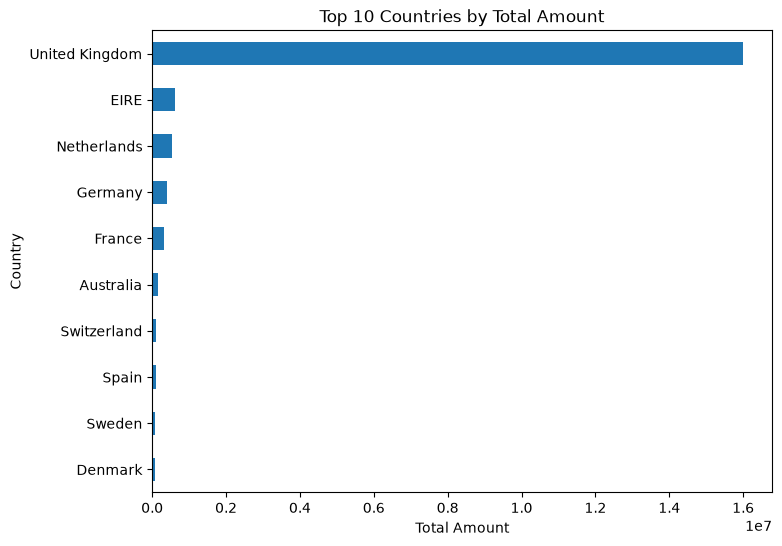

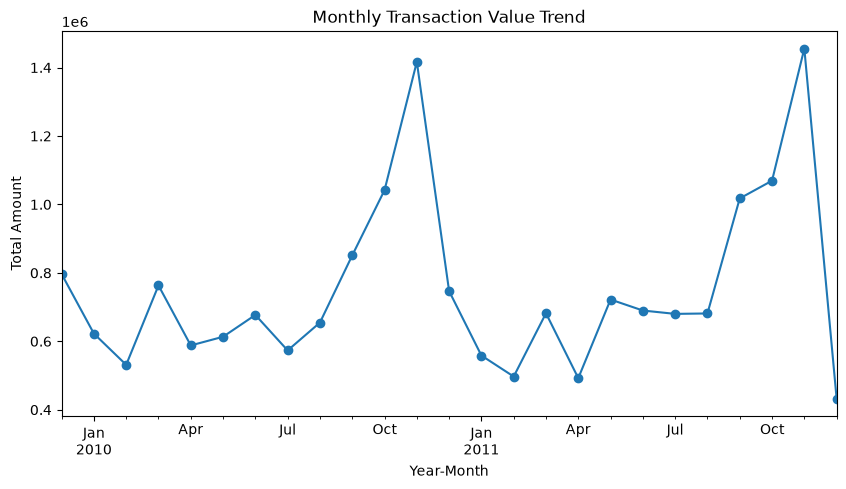

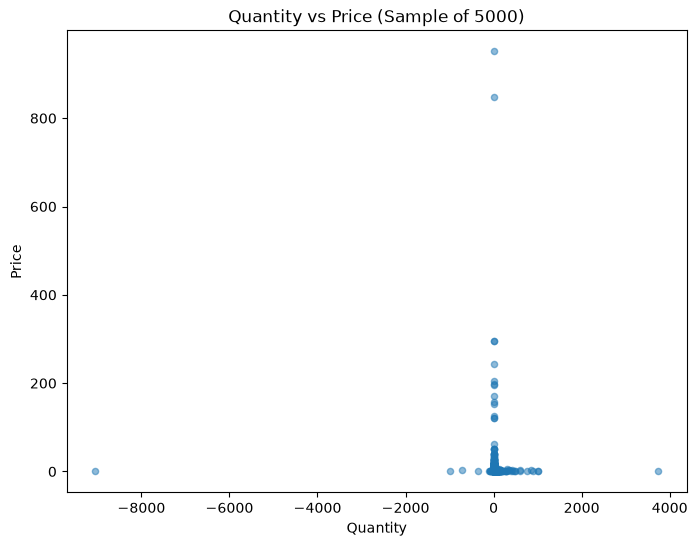

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# S1
top_10_countries = retail_final.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)

ax1 = top_10_countries.sort_values(ascending=True).plot(
    kind='barh', 
    title='Top 10 Countries by Total Amount',
    figsize=(8, 6)
)
ax1.set_xlabel('Total Amount')
ax1.set_ylabel('Country')
plt.show()


# S2
retail_final['InvoiceDate'] = pd.to_datetime(retail_final['InvoiceDate'])

retail_final['YearMonth'] = retail_final['InvoiceDate'].dt.to_period('M')
monthly_trend = retail_final.groupby('YearMonth')['TotalAmount'].sum()

ax2 = monthly_trend.plot(
    kind='line', 
    title='Monthly Transaction Value Trend',
    figsize=(10, 5),
    marker='o'
)
ax2.set_xlabel('Year-Month')
ax2.set_ylabel('Total Amount')
plt.show()


# S3
sample_df = retail_final.sample(n=min(5000, len(retail_final)), random_state=42)

ax3 = sample_df.plot(
    kind='scatter', 
    x='Quantity', 
    y='Price', 
    title='Quantity vs Price (Sample of 5000)',
    figsize=(8, 6),
    alpha=0.5
)
plt.show()


- Extreme quantities or prices can indicate outliers such as wholesale orders, data entry errors, or special transactions. These extreme values can significantly skew the visual scale of the scatter plot, compressing the majority of the data points into a small cluster and making it difficult to observe the general distribution among typical transactions. Identifying them helps you decide whether to investigate further, filter them out, or apply scale transformations for clearer visualization.


# Part T — Lesson 3 business interpretation

Write **150–200 words** summarizing what the aggregation stage adds to the earlier data-quality audit.

Your discussion should include:
1. the countries with the largest net transaction value;
2. the difference between transaction-line frequency and aggregated value;
3. what the completed/cancelled comparison shows;
4. one product-level result;
5. one pattern visible in the monthly chart;
6. one caution about interpreting net value because returns/cancellations are included.


## Updated submission checklist

Submit one Jupyter Notebook containing:
- your Python code;
- outputs for every task;
- short written interpretations where requested;
- the original data-quality work from Parts A–M;
- the Lesson 3 extension from Parts N–T;
- the final Lesson 3 business interpretation.

Suggested filename: `StudentID_Project1_OnlineRetail_Lessons1to3.ipynb`


The aggregation stage provides crucial business insights that extend beyond the initial data-quality audit. While the audit ensured data integrity by handling missing values and anomalies, aggregation reveals the actual commercial performance and revenue impact of the dataset.

First, the United Kingdom dominates as the country with the largest net transaction value, significantly outpacing others like the Netherlands, EIRE, and Germany. Second, comparing transaction-line frequency with aggregated value highlights that while some countries have a lower frequency of transactions, they generate a higher aggregated value due to larger wholesale orders. Third, the completed versus cancelled comparison shows that cancellations substantially offset gross revenue, proving that focusing solely on completed orders would overestimate actual net income. 

At a product level, specific top-selling items—such as the 'WHITE HANGING HEART T-LIGHT HOLDER'—drive a disproportionate share of the total quantity sold and revenue. Furthermore, the monthly transaction-value trend reveals strong seasonality, with a clear revenue peak in November leading up to the holiday season. Finally, caution is necessary when interpreting 'net value' since it incorporates returns and cancellations as negative amounts; a single large cancelled order can severely skew the net revenue downwards for a specific country or period.
